In [1]:
import os
import keras
import random

2022-06-24 15:18:38.152025: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2022-06-24 15:18:38.156585: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-06-24 15:18:38.156599: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
classes = {0:"background",1:"buisson",2:"champs",3:"eau",
         4:"falaise",5:"foret_dense",6:"foret_claire",
         7:"pierrier",8:"prairie",9:"route",10:"verger",
         11:"batiment"}

In [3]:
import numpy as np
import tensorflow as tf
from keras import backend as K
import matplotlib.pyplot as plt
import segmentation_models as sm
from utils import visualize, freeze_session
from data_loader import Dataset, Dataloader
from keras.backend import set_session
from augmentation import *

Segmentation Models: using `keras` framework.


In [4]:
# Tensorflow session
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True  # dynamically grow the memory used on the GPU
config.log_device_placement = False  # to log device placement (on which device the operation ran)
sess = tf.compat.v1.Session(config=config)
set_session(sess)  # set this TensorFlow session as the default session for Keras

train_dir = "Real/Train/"
test_dir = "Real/Valid/"
result_dir = "Real/Result/"
image_size = 512
image_channels = 3
padding_size = 800
n_classes = 12

# model parameters
BACKBONE = 'efficientnetb3'
BATCH_SIZE = 8
LR = 0.001
EPOCHS = 250
activation ='softmax'

2022-06-24 15:18:40.679742: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-06-24 15:18:40.765519: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/hugo/new_ampli/env/lib/python3.9/site-packages/cv2/../../lib64:
2022-06-24 15:18:40.765574: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/hugo/new_ampli/env/lib/python3.9/site-packages/cv2/../../lib64:
2022-0

In [5]:
# define network parameters 
preprocess_input = sm.get_preprocessing(BACKBONE)

In [6]:
if not os.path.exists(result_dir):
    os.mkdir(result_dir)
    
x_train_dir = os.path.join(train_dir, 'images')
y_train_dir = os.path.join(train_dir, 'masks')
x_valid_dir = os.path.join(test_dir, 'images')
y_valid_dir = os.path.join(test_dir, 'masks')

# Dataset for train images
train_dataset = Dataset(
    x_train_dir, 
    y_train_dir, 
    classes=n_classes, 
    augmentation=False,
    preprocessing=get_preprocessing(preprocess_input),
    #preprocessing=False,
)

# Dataset for validation images
valid_dataset = Dataset(
    x_valid_dir, 
    y_valid_dir, 
    classes=n_classes, 
    augmentation=False,
    preprocessing=get_preprocessing(preprocess_input),
    #preprocessing=False,
)

/home/hugo/new_ampli/env/lib/python3.9/site-packages/albumentations/augmentations/transforms.py:2567: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  warnings.warn('Using lambda is incompatible with multiprocessing. '


In [7]:
#create model
model = sm.Unet(BACKBONE,classes=n_classes, activation=activation)

# define optomizer
optim = keras.optimizers.Adam(LR)

# Segmentation models losses can be combined together by '+' and scaled by integer or float factor
dice_loss = sm.losses.DiceLoss(class_weights=np.ones(n_classes)) 
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]

# compile keras model with defined optimozer, loss and metrics
model.compile(optim, total_loss, metrics)

2022-06-24 15:18:43.312883: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1850] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
BATCH_SIZE = 8
#Dataloaders
train_dataloader = Dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = Dataloader(valid_dataset, batch_size=1, shuffle=False)

# check shapes for errors
assert train_dataloader[0][0].shape == (BATCH_SIZE, image_size, image_size, image_channels)
assert train_dataloader[0][1].shape == (BATCH_SIZE, image_size, image_size, n_classes)


In [6]:
# define callbacks for learning rate scheduling and best checkpoints saving
callbacks = [
    keras.callbacks.ModelCheckpoint(os.path.join(result_dir,'best_model.h5'), save_weights_only=True, save_best_only=True, mode='min'),
    keras.callbacks.ReduceLROnPlateau(),
]

# train model
history = model.fit(
    train_dataloader, 
    steps_per_epoch=len(train_dataloader), 
    epochs=EPOCHS, 
    callbacks=callbacks, 
    validation_data=valid_dataloader, 
    validation_steps=len(valid_dataloader),
)

Epoch 1/250
26/26 [==============================] - 242s 9s/step - loss: 0.8722 - iou_score: 0.1251 - f1-score: 0.1552 - val_loss: 1.0308 - val_iou_score: 0.3549 - val_f1-score: 0.3747 - lr: 0.0010
Epoch 2/250
26/26 [==============================] - 211s 8s/step - loss: 0.7189 - iou_score: 0.2558 - f1-score: 0.3081 - val_loss: 1.0698 - val_iou_score: 0.2916 - val_f1-score: 0.3038 - lr: 0.0010
Epoch 3/250
26/26 [==============================] - 205s 8s/step - loss: 0.6203 - iou_score: 0.3682 - f1-score: 0.4478 - val_loss: 0.9649 - val_iou_score: 0.3771 - val_f1-score: 0.4024 - lr: 0.0010
Epoch 4/250
26/26 [==============================] - 205s 8s/step - loss: 0.5351 - iou_score: 0.4457 - f1-score: 0.5437 - val_loss: 0.9491 - val_iou_score: 0.3053 - val_f1-score: 0.3333 - lr: 0.0010
Epoch 5/250
26/26 [==============================] - 205s 8s/step - loss: 0.4913 - iou_score: 0.4755 - f1-score: 0.5718 - val_loss: 0.9230 - val_iou_score: 0.3569 - val_f1-score: 0.3881 - lr: 0.0010
Epoch

26/26 [==============================] - 205s 8s/step - loss: 0.1805 - iou_score: 0.7696 - f1-score: 0.8349 - val_loss: 0.7705 - val_iou_score: 0.5204 - val_f1-score: 0.5609 - lr: 0.0010
Epoch 43/250
26/26 [==============================] - 205s 8s/step - loss: 0.1757 - iou_score: 0.7762 - f1-score: 0.8390 - val_loss: 0.7703 - val_iou_score: 0.5228 - val_f1-score: 0.5629 - lr: 1.0000e-04
Epoch 44/250
26/26 [==============================] - 205s 8s/step - loss: 0.1723 - iou_score: 0.7808 - f1-score: 0.8421 - val_loss: 0.7700 - val_iou_score: 0.5218 - val_f1-score: 0.5618 - lr: 1.0000e-04
Epoch 45/250
26/26 [==============================] - 204s 8s/step - loss: 0.1708 - iou_score: 0.7832 - f1-score: 0.8437 - val_loss: 0.7697 - val_iou_score: 0.5203 - val_f1-score: 0.5603 - lr: 1.0000e-04
Epoch 46/250
26/26 [==============================] - 205s 8s/step - loss: 0.1702 - iou_score: 0.7840 - f1-score: 0.8442 - val_loss: 0.7697 - val_iou_score: 0.5204 - val_f1-score: 0.5603 - lr: 1.0000e-

26/26 [==============================] - 206s 8s/step - loss: 0.1660 - iou_score: 0.7895 - f1-score: 0.8478 - val_loss: 0.7704 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-11
Epoch 123/250
26/26 [==============================] - 205s 8s/step - loss: 0.1654 - iou_score: 0.7936 - f1-score: 0.8516 - val_loss: 0.7704 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-12
Epoch 124/250
26/26 [==============================] - 205s 8s/step - loss: 0.1655 - iou_score: 0.7903 - f1-score: 0.8483 - val_loss: 0.7704 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-12
Epoch 125/250
26/26 [==============================] - 206s 8s/step - loss: 0.1661 - iou_score: 0.7929 - f1-score: 0.8509 - val_loss: 0.7703 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-12
Epoch 126/250
26/26 [==============================] - 206s 8s/step - loss: 0.1667 - iou_score: 0.7887 - f1-score: 0.8472 - val_loss: 0.7703 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 

26/26 [==============================] - 217s 8s/step - loss: 0.1663 - iou_score: 0.7924 - f1-score: 0.8508 - val_loss: 0.7703 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-15
Epoch 163/250
26/26 [==============================] - 217s 8s/step - loss: 0.1670 - iou_score: 0.7886 - f1-score: 0.8467 - val_loss: 0.7704 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-16
Epoch 164/250
26/26 [==============================] - 212s 8s/step - loss: 0.1664 - iou_score: 0.7890 - f1-score: 0.8473 - val_loss: 0.7703 - val_iou_score: 0.5173 - val_f1-score: 0.5572 - lr: 1.0000e-16
Epoch 165/250
26/26 [==============================] - 208s 8s/step - loss: 0.1666 - iou_score: 0.7888 - f1-score: 0.8473 - val_loss: 0.7703 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-16
Epoch 166/250
26/26 [==============================] - 215s 8s/step - loss: 0.1657 - iou_score: 0.7933 - f1-score: 0.8513 - val_loss: 0.7704 - val_iou_score: 0.5173 - val_f1-score: 0.5572 - lr: 

26/26 [==============================] - 215s 8s/step - loss: 0.1656 - iou_score: 0.7936 - f1-score: 0.8515 - val_loss: 0.7703 - val_iou_score: 0.5173 - val_f1-score: 0.5573 - lr: 1.0000e-19
Epoch 203/250
26/26 [==============================] - 216s 8s/step - loss: 0.1668 - iou_score: 0.7916 - f1-score: 0.8503 - val_loss: 0.7704 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-20
Epoch 204/250
26/26 [==============================] - 216s 8s/step - loss: 0.1664 - iou_score: 0.7889 - f1-score: 0.8474 - val_loss: 0.7703 - val_iou_score: 0.5173 - val_f1-score: 0.5572 - lr: 1.0000e-20
Epoch 205/250
26/26 [==============================] - 217s 8s/step - loss: 0.1673 - iou_score: 0.7882 - f1-score: 0.8465 - val_loss: 0.7703 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-20
Epoch 206/250
26/26 [==============================] - 216s 8s/step - loss: 0.1656 - iou_score: 0.7901 - f1-score: 0.8482 - val_loss: 0.7704 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 

26/26 [==============================] - 215s 8s/step - loss: 0.1659 - iou_score: 0.7899 - f1-score: 0.8479 - val_loss: 0.7703 - val_iou_score: 0.5173 - val_f1-score: 0.5573 - lr: 1.0000e-23
Epoch 243/250
26/26 [==============================] - 215s 8s/step - loss: 0.1652 - iou_score: 0.7909 - f1-score: 0.8487 - val_loss: 0.7703 - val_iou_score: 0.5173 - val_f1-score: 0.5573 - lr: 1.0000e-24
Epoch 244/250
26/26 [==============================] - 216s 8s/step - loss: 0.1652 - iou_score: 0.7939 - f1-score: 0.8518 - val_loss: 0.7703 - val_iou_score: 0.5172 - val_f1-score: 0.5572 - lr: 1.0000e-24
Epoch 245/250
26/26 [==============================] - 218s 8s/step - loss: 0.1657 - iou_score: 0.7901 - f1-score: 0.8482 - val_loss: 0.7703 - val_iou_score: 0.5173 - val_f1-score: 0.5573 - lr: 1.0000e-24
Epoch 246/250
26/26 [==============================] - 217s 8s/step - loss: 0.1658 - iou_score: 0.7900 - f1-score: 0.8481 - val_loss: 0.7703 - val_iou_score: 0.5173 - val_f1-score: 0.5573 - lr: 

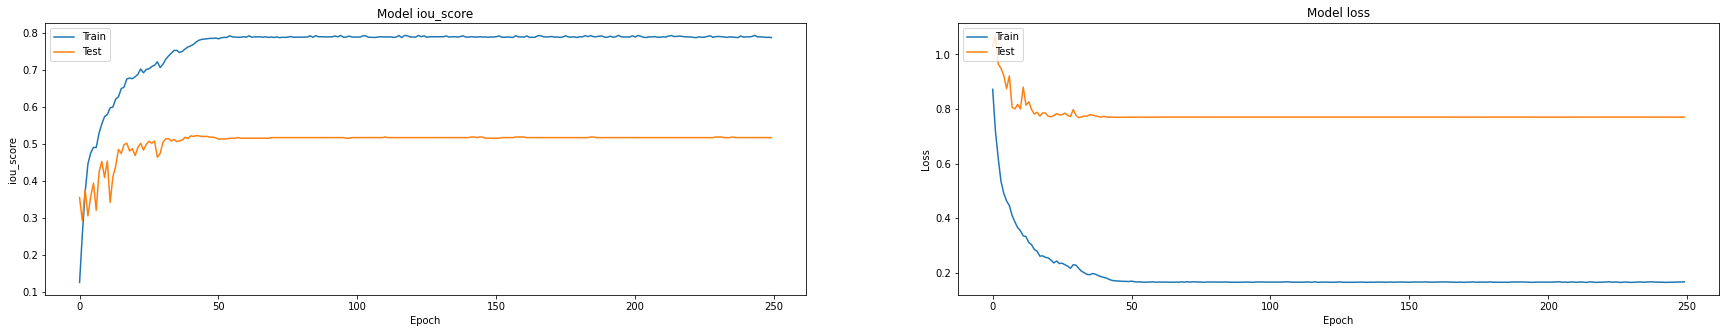

In [7]:

# Plot training & validation iou_score values
plt.figure(figsize=(30, 5))
plt.subplot(121)
plt.plot(history.history['iou_score'])
plt.plot(history.history['val_iou_score'])
plt.title('Model iou_score')
plt.ylabel('iou_score')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig(os.path.join(result_dir,'UNET-Training.png'))
plt.show()

#Save model as Tensorflow frozen graph
#frozen_graph = freeze_session(K.get_session(),output_names=[out.op.name for out in model.outputs])
#tf.train.write_graph(frozen_graph, result_dir , "best_model.pb", as_text=False)

In [8]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 4848586828533709014
xla_global_id: -1
]


2022-06-21 09:50:12.566331: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1850] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Modèle entraîné sur le jeu réelle et testé sur le jeu de validation réelle

In [9]:
train_imgs=[]
train_labels=[]

for img,label in train_dataset:
    train_imgs.append(img)
    train_labels.append(label)
    
train_imgs = np.array(train_imgs)
train_labels = np.array(train_labels)

In [21]:
model.load_weights(os.path.join(result_dir,'best_model.h5'))

In [11]:
predictions = model.predict(train_imgs)

7/7 [==============================] - 60s 8s/step


In [12]:
true_label = np.argmax(train_labels,axis=3)
label_pred = np.argmax(predictions,axis=3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


135


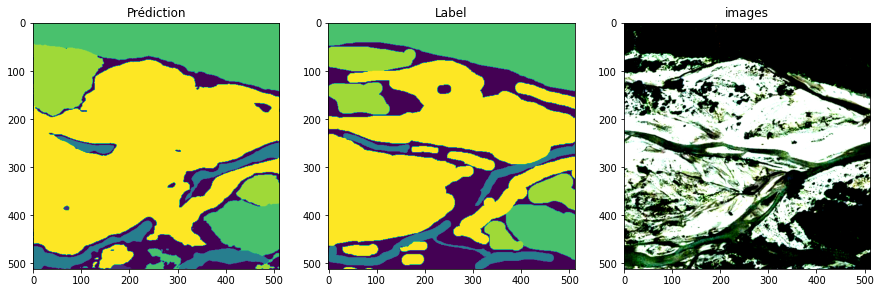

In [13]:
i=random.choice(range(len(train_imgs)-1))
print(i)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(label_pred[i])
plt.gca().set_title("Prédiction")

plt.subplot(132)
plt.imshow(true_label[i])
plt.gca().set_title("Label")

plt.subplot(133)
plt.imshow(train_imgs[i])
plt.gca().set_title("images")
plt.show()

In [22]:
valid_imgs=[]
valid_labels=[]

for img,label in valid_dataset:
    valid_imgs.append(img)
    valid_labels.append(label)
    
valid_imgs = np.array(valid_imgs)
valid_labels = np.array(valid_labels)

In [23]:
predictions = model.predict(valid_imgs)

2/2 [==============================] - 13s 5s/step


In [24]:
true_label = np.argmax(valid_labels,axis=3)
label_pred = np.argmax(predictions,axis=3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


8


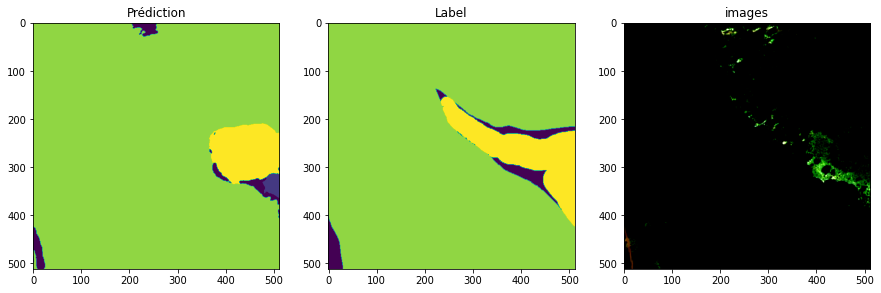

In [25]:
i=random.choice(range(len(valid_imgs)-1))
print(i)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(label_pred[i])
plt.gca().set_title("Prédiction")

plt.subplot(132)
plt.imshow(true_label[i])
plt.gca().set_title("Label")

plt.subplot(133)
plt.imshow(valid_imgs[i])
plt.gca().set_title("images")
plt.show()

### avec seuil

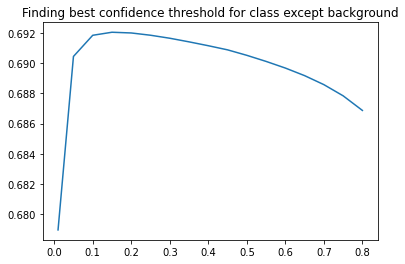

In [113]:
ious = []
threshold_iou = [0.01,0.05,0.1,0.15,0.2,
                 0.25,0.3,0.35,0.4,0.45,0.5,
                 0.55,0.6,0.65,0.7,0.75,0.8]

for threshold in threshold_iou:
    iou = []
    for idx_classe in range(1,12):
        prediction = np.where(predictions[...,idx_classe]<= threshold,0,1)
        target = valid_labels[...,idx_classe]

        intersection = np.logical_and(target,prediction)
        union = np.logical_or(target,prediction)
        iou_score = np.sum(intersection) / np.sum(union)

        # print("iou score for class", classes[idx_classe], ": with 0.5 threshold ",iou_score)
        iou.append(iou_score)
    ious.append(np.mean(iou))
    
plt.plot(threshold_iou,ious)
plt.gca().set_title("Finding best confidence threshold for class except background")
plt.show()

In [114]:
best_threshold = 0.2

In [115]:
conf_mat = np.zeros((12,12))

for idx_pred_class in range(12):
    for idx_target_class in range(12):
        prediction = np.where(predictions[...,idx_pred_class]<= best_threshold,0,1)
        target = valid_labels[...,idx_target_class]

        intersection = np.logical_and(target,prediction)
        conf_mat[idx_pred_class,idx_target_class] = np.sum(intersection)

### Avec l'Argmax

In [26]:
prediction = np.zeros(predictions.shape)

for idx_class in range(12):
    prediction[...,idx_class][label_pred == idx_class] = 1

In [27]:
conf_mat = np.zeros((12,12))

for idx_pred_class in range(12):
    for idx_target_class in range(12):
        target = valid_labels[...,idx_target_class]

        intersection = np.logical_and(target,prediction[...,idx_pred_class])
        conf_mat[idx_pred_class,idx_target_class] = np.sum(intersection)

In [28]:
assert np.sum(conf_mat) == 51*512*512

In [29]:
classe = list(classes.values())

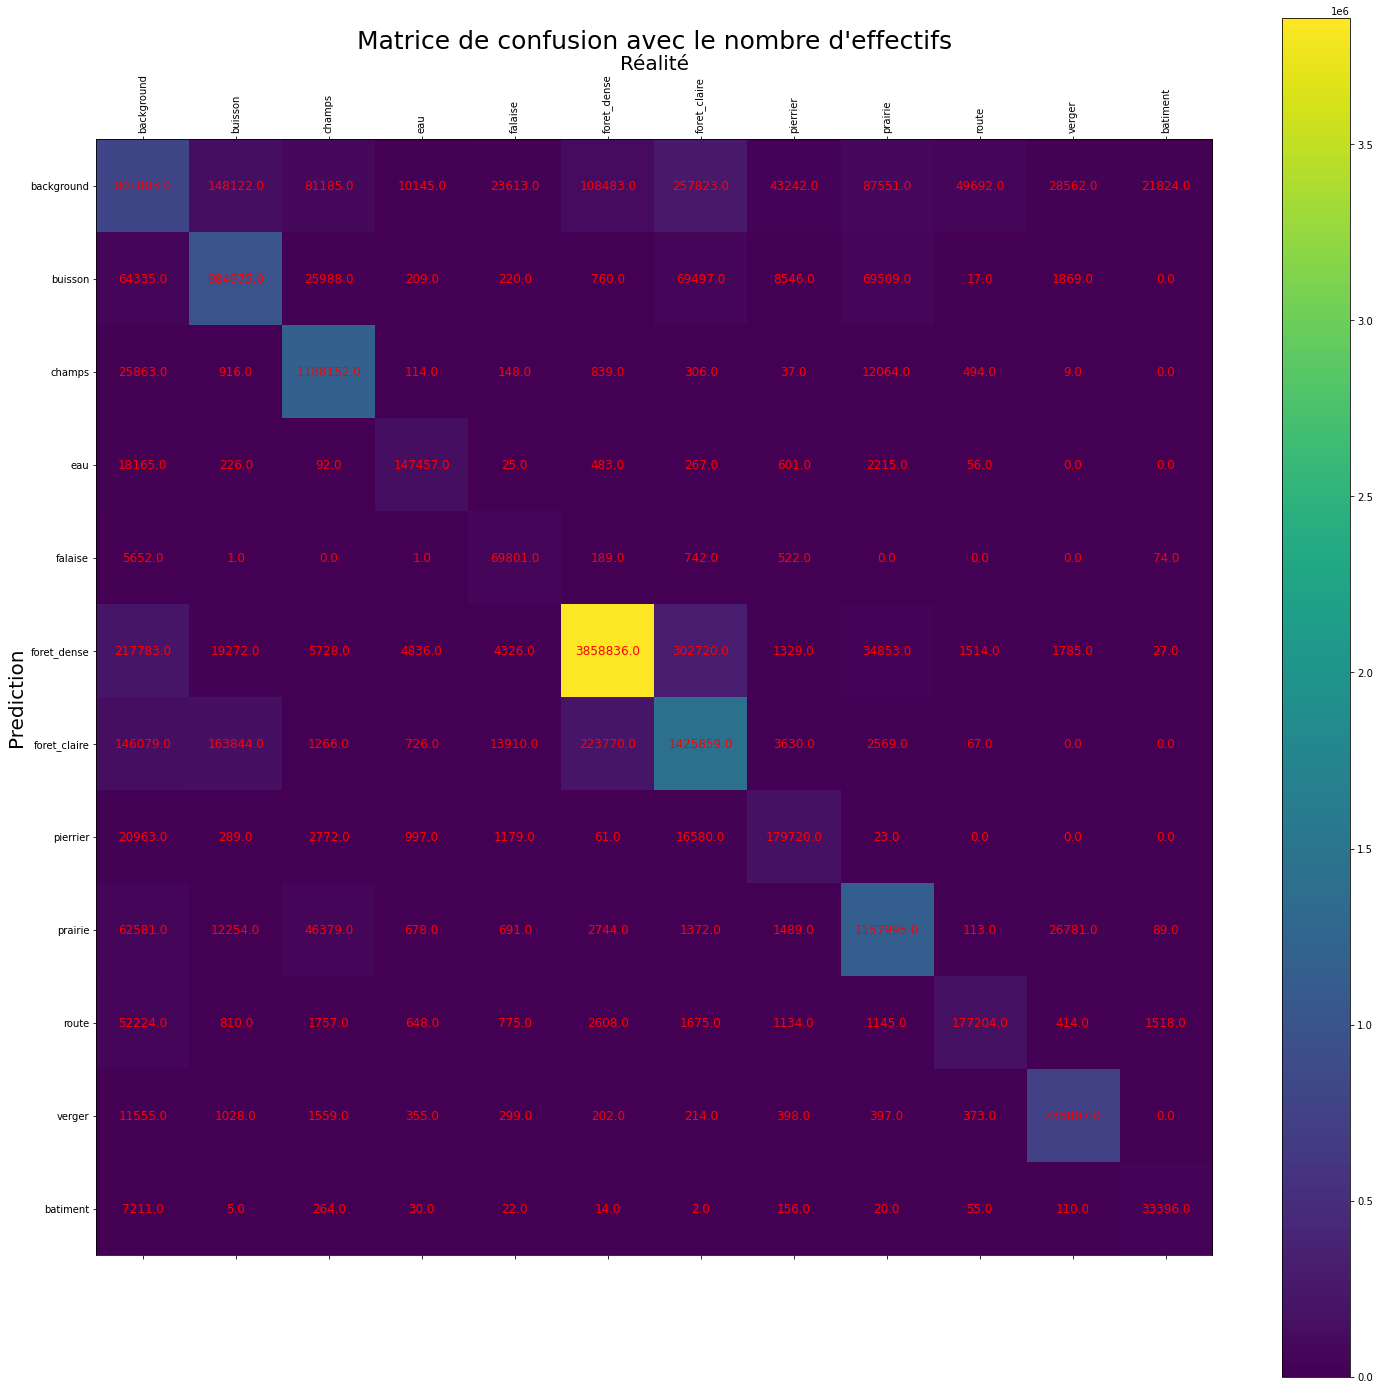

In [30]:
data = conf_mat

fig = plt.figure(figsize=(25,25))
ax = fig.add_subplot(111)
cax = ax.matshow(data, interpolation='nearest')
fig.colorbar(cax)

for i in range(len(data)):
    for j in range(len(data)):
        c = data[j,i]
        ax.text(i, j, str(round(c,2)), va='center', ha='center',
                color="red",size = "large")
        
plt.xticks(range(12), classe, rotation='vertical')
plt.yticks(range(12), classe, rotation='horizontal')
plt.xlabel('Réalité', fontsize=20)
plt.gca().xaxis.set_label_position('top') 
plt.ylabel('Prediction', fontsize=20)
plt.gca().set_title("Matrice de confusion avec le nombre d'effectifs", fontsize=25)
plt.show()
plt.show()

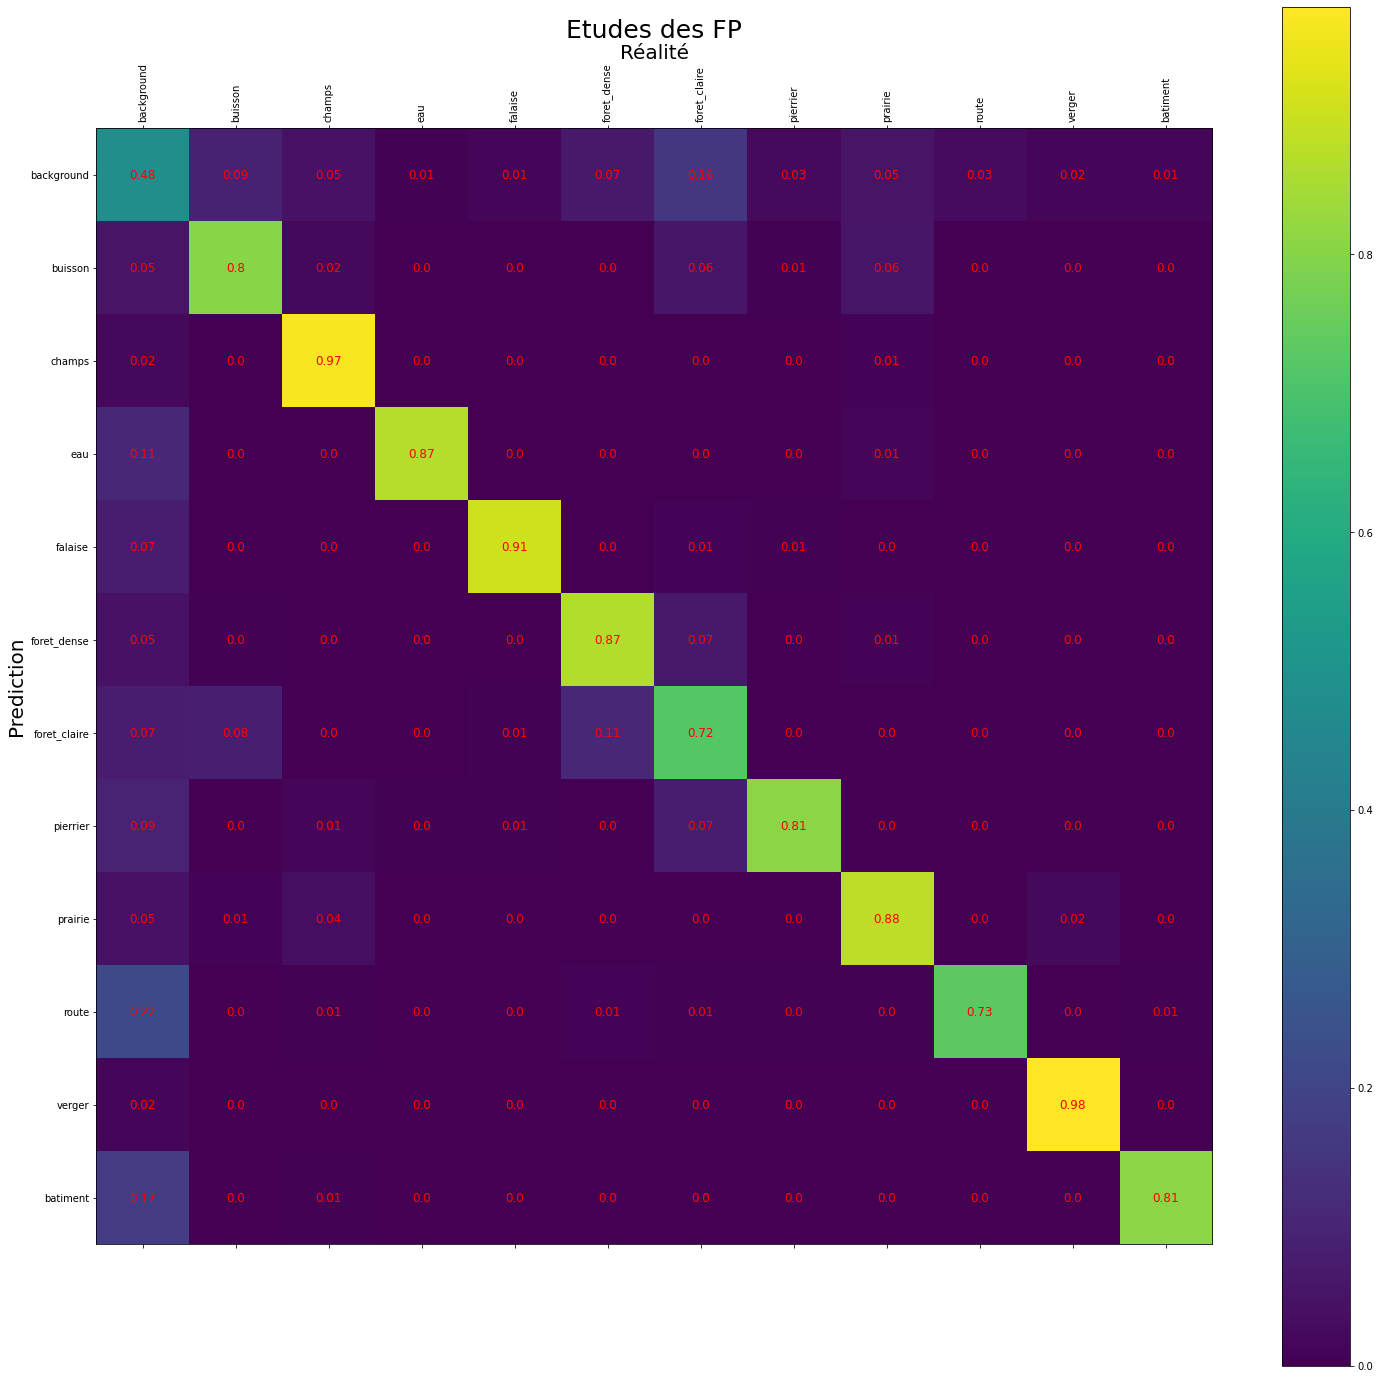

In [31]:
conf_mat_norm = conf_mat.T/conf_mat.sum(axis=1)

conf_mat_norm = conf_mat_norm.T

data = conf_mat_norm

fig = plt.figure(figsize=(25,25))
ax = fig.add_subplot(111)
cax = ax.matshow(data, interpolation='nearest')
fig.colorbar(cax)

for i in range(len(data)):
    for j in range(len(data)):
        c = data[j,i]
        ax.text(i, j, str(round(c,2)), va='center', ha='center',
                color="red",size = "large")
        
plt.xticks(range(12), classe, rotation='vertical')
plt.yticks(range(12), classe, rotation='horizontal')
plt.xlabel('Réalité', fontsize=20)
plt.gca().xaxis.set_label_position('top') 
plt.ylabel('Prediction', fontsize=20)
plt.gca().set_title("Etudes des FP", fontsize=25)
plt.show()
plt.show()

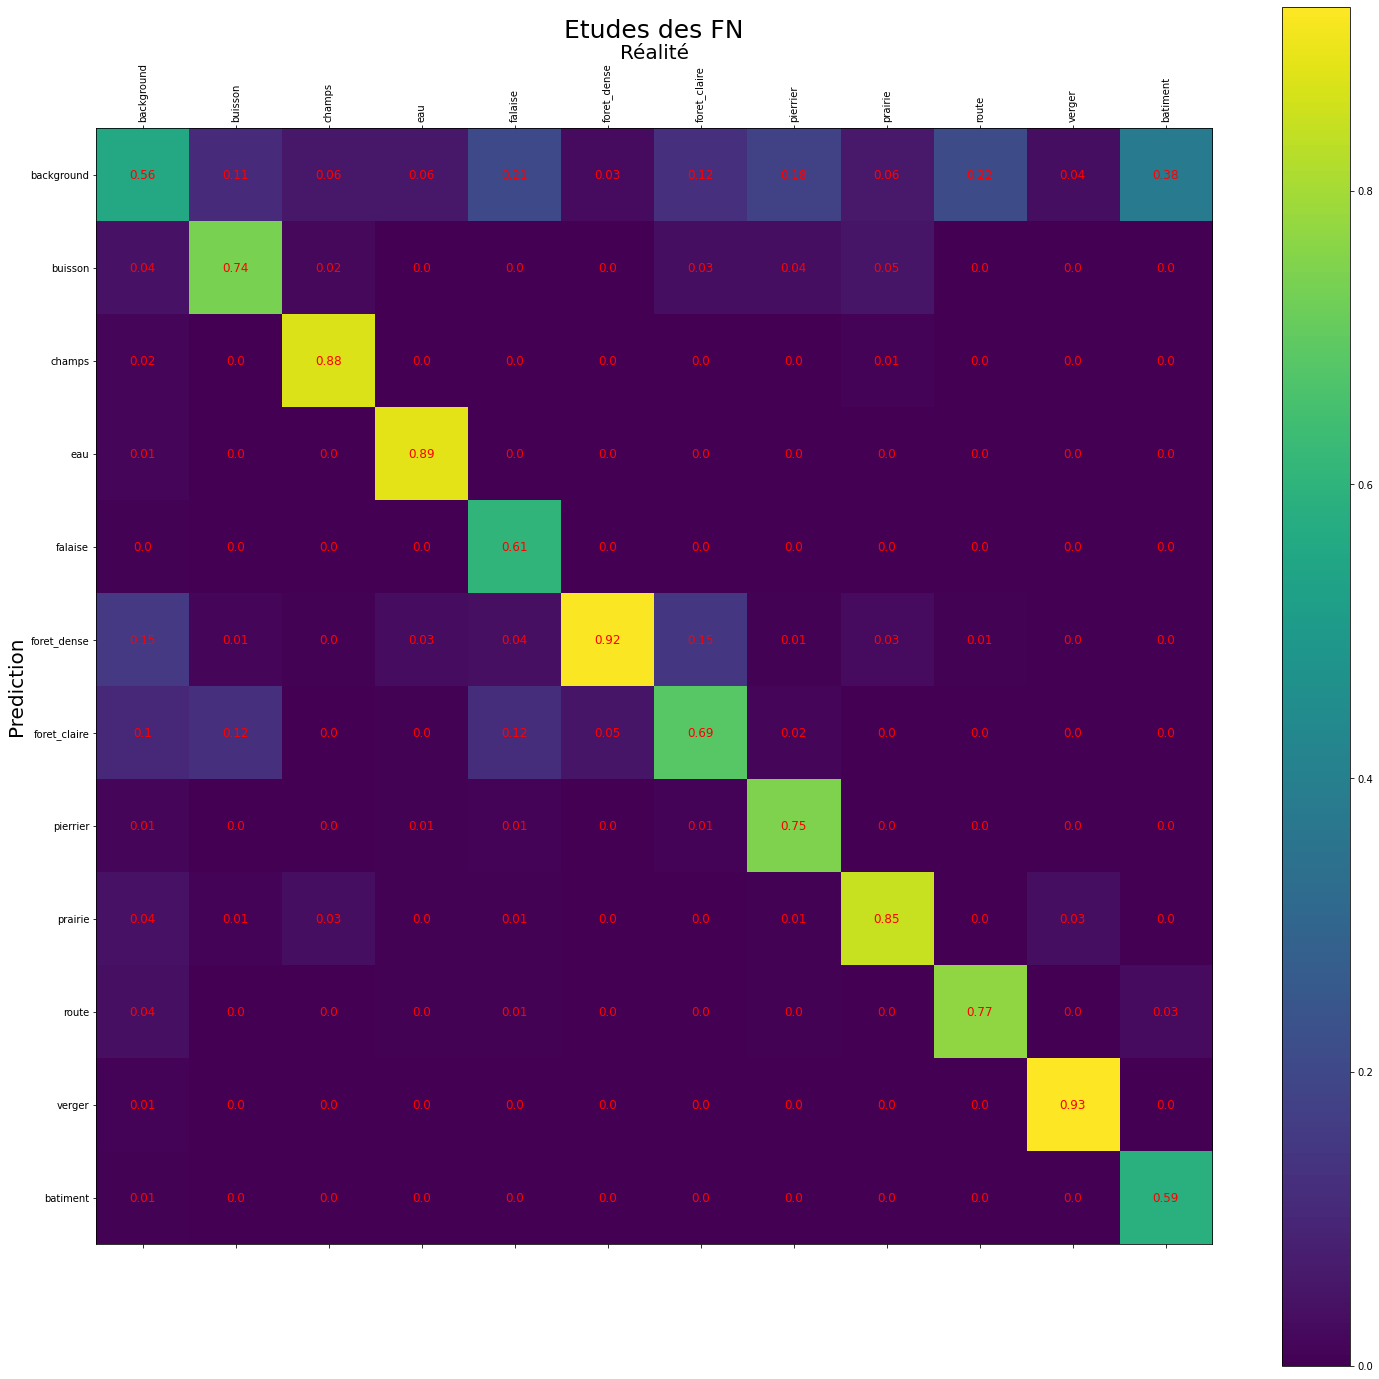

In [32]:
conf_mat_norm_bis = conf_mat / conf_mat.sum(axis=0)

data = conf_mat_norm_bis

fig = plt.figure(figsize=(25,25))
ax = fig.add_subplot(111)
cax = ax.matshow(data, interpolation='nearest')
fig.colorbar(cax)

for i in range(len(data)):
    for j in range(len(data)):
        c = data[j,i]
        ax.text(i, j, str(round(c,2)), va='center', ha='center',
                color="red",size = "large")
        
plt.xticks(range(12), classe, rotation='vertical')
plt.yticks(range(12), classe, rotation='horizontal')
plt.xlabel('Réalité', fontsize=20)
plt.gca().xaxis.set_label_position('top') 
plt.ylabel('Prediction', fontsize=20)
plt.gca().set_title("Etudes des FN", fontsize=25)
plt.show()
plt.show()

In [33]:
dico = {}
for key in classes:
    precision = conf_mat[key,key]/np.sum(conf_mat[key,:])
    recall = conf_mat[key,key]/np.sum(conf_mat[:,key])
    f1score = 2 * precision * recall /(precision + recall)
    dico[classes[key]] = {"precision":precision,"recall":recall,"f1":f1score}
    
dico

{'background': {'precision': 0.48241954941051535,
  'recall': 0.5590539487133719,
  'f1': 0.517917267257035},
 'buisson': {'precision': 0.8034545343312193,
  'recall': 0.7396139792842757,
  'f1': 0.7702136360988354},
 'champs': {'precision': 0.9668088485868332,
  'recall': 0.8767730614208695,
  'f1': 0.9195923971511761},
 'eau': {'precision': 0.8695065069846155,
  'recall': 0.8872475871862139,
  'f1': 0.878287465416653},
 'falaise': {'precision': 0.906718453664493,
  'recall': 0.6069177194828231,
  'f1': 0.7271278341172243},
 'foret_dense': {'precision': 0.8665682014116747,
  'recall': 0.9189916906188609,
  'f1': 0.8920103772562129},
 'foret_claire': {'precision': 0.7195057828552974,
  'recall': 0.6864804384280259,
  'f1': 0.702605242909379},
 'pierrier': {'precision': 0.8074255112676563,
  'recall': 0.7463331173900766,
  'f1': 0.7756782652981952},
 'prairie': {'precision': 0.8818344367734163,
  'recall': 0.8462766225670355,
  'f1': 0.8636897088092629},
 'route': {'precision': 0.732514

In [34]:
sommef1,sommerecall,sommeprecision = 0,0,0
for key in dico:
    sommef1 += dico[key]["f1"]
    sommerecall += dico[key]["recall"]
    sommeprecision += dico[key]["precision"]
    
print("mean f1 score is:" ,sommef1/len(dico))
print("mean precision score is:" ,sommeprecision/len(dico))
print("mean recall score is:" ,sommerecall/len(dico))

mean f1 score is: 0.7858173321767269
mean precision score is: 0.8186577731088039
mean recall score is: 0.7626099992673456


## Modèle entrainé sur le jeu Réelle testé sur le Jeu de validation de Synthese

In [8]:
syn_dir = "Synthese/Valid/"

x_valid_dir = os.path.join(syn_dir, 'images')
y_valid_dir = os.path.join(syn_dir, 'masks')

# Dataset for validation images
valid_dataset_syn = Dataset(
    x_valid_dir, 
    y_valid_dir, 
    classes=n_classes, 
    augmentation=False,
    preprocessing=get_preprocessing(preprocess_input),
    #preprocessing=False,
)

In [9]:
model.load_weights(os.path.join(result_dir,'best_model.h5'))

In [10]:
valid_imgs_syn =[]
valid_labels_syn =[]

for img,label in valid_dataset_syn:
    valid_imgs_syn.append(img)
    valid_labels_syn.append(label)
    
valid_imgs_syn = np.array(valid_imgs_syn)
valid_labels_syn = np.array(valid_labels_syn)


In [11]:
predictions = model.predict(valid_imgs_syn)
predictions.shape

6/6 [==============================] - 45s 7s/step


(170, 512, 512, 12)

In [12]:
true_label = np.argmax(valid_labels_syn,axis=3)
label_pred = np.argmax(predictions,axis=3)

In [13]:
np.unique(true_label),np.unique(label_pred)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]))

In [14]:
classes_real = {0:"background",1:"buisson",2:"champs",3:"eau",
         4:"falaise",5:"foret_dense",6:"foret_claire",
         7:"pierrier",8:"prairie",9:"route",10:"verger",
         11:"batiment"}

classes_syn = {0: "falaise" , 1: "batiment", 2:"route",3:"pierrier",4:"verger",
            5:"champ",6:"prairie",7:"foret",8:"foret_claire",9:"buisson",10:"eau"}


correspondance = {0:4,1:11,2:9,3:7,4:10,5:2,6:8,7:5,8:6,9:1,10:3,11:0}

In [15]:
"""
def f(x):
    return correspondance[x]

vfunc = np.vectorize(f)
true_label = vfunc(true_label)
"""

'\ndef f(x):\n    return correspondance[x]\n\nvfunc = np.vectorize(f)\ntrue_label = vfunc(true_label)\n'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


105


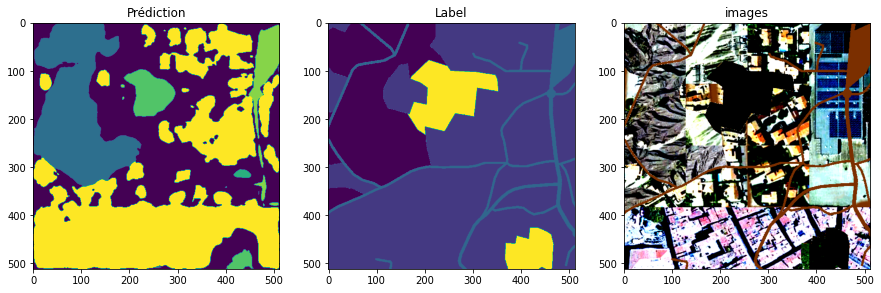

In [16]:
i=random.choice(range(len(valid_imgs_syn)-1))
#i = 45
print(i)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(label_pred[i])
plt.gca().set_title("Prédiction")

plt.subplot(132)
plt.imshow(true_label[i])
plt.gca().set_title("Label")

plt.subplot(133)
plt.imshow(valid_imgs_syn[i])
plt.gca().set_title("images")
plt.show()

In [17]:
prediction = np.zeros(predictions.shape)

for idx_class in range(12):
    prediction[...,idx_class][label_pred == idx_class] = 1

In [ ]:
conf_mat = np.zeros((12,11))

for idx_pred_class in range(12):
    for idx_target_class in range(11):
        target = valid_labels_syn[...,idx_target_class]

        intersection = np.logical_and(target,prediction[...,correspondance[idx_pred_class]])
        conf_mat[idx_pred_class,idx_target_class] = np.sum(intersection)

In [ ]:
#for i in range(11):
#    print(i)
#    print(np.sum(conf_mat[i,:])/len(label_pred[label_pred == correspondance[i]]))

In [ ]:
assert np.sum(conf_mat.flatten())/len(true_label.flatten()) == 1.0

In [ ]:
a = list(classes_syn.values())
a.append("background")

In [ ]:
shape = conf_mat.shape
data = conf_mat

fig = plt.figure(figsize=(25,25))
ax = fig.add_subplot(111)
cax = ax.matshow(data, interpolation='nearest')
fig.colorbar(cax)

for i in range(shape[1]):
    for j in range(shape[0]):
        c = data[j,i]
        ax.text(i, j, str(round(c,2)), va='center', ha='center',
                color="red",size = "large")
        
plt.xticks(range(11), list(classes_syn.values()), rotation='vertical')
plt.yticks(range(12), a, rotation='horizontal')
plt.xlabel('Réalité', fontsize=20)
plt.gca().xaxis.set_label_position('top')
plt.gca().set_title("Matrice de confusion avec le nombre d'effectifs", fontsize=25)
plt.ylabel('Prediction', fontsize=20)
plt.show()

In [ ]:
target = valid_labels_syn[...,0]

intersection = np.logical_and(target,prediction[...,0])

In [ ]:
conf_mat_norm = conf_mat[:-1,:].T / conf_mat[:-1,:].sum(axis=1)

conf_mat_norm = conf_mat_norm.T

shape = conf_mat.shape
data = conf_mat_norm

fig = plt.figure(figsize=(25,25))
ax = fig.add_subplot(111)
cax = ax.matshow(data, interpolation='nearest')
fig.colorbar(cax)

for i in range(11):
    for j in range(11):
        c = data[j,i]
        ax.text(i, j, str(round(c,2)), va='center', ha='center',
                color="red",size = "large")
        
plt.xticks(range(11), list(classes_syn.values()), rotation='vertical')
plt.yticks(range(11), list(classes_syn.values()), rotation='horizontal')
plt.xlabel('Réalité', fontsize=20)
plt.gca().xaxis.set_label_position('top') 
plt.ylabel('Prediction', fontsize=20)
plt.gca().set_title("Etudes des FP", fontsize=25)
plt.show()

In [ ]:
conf_mat_norm_bis = conf_mat[:-1,:] / conf_mat[:-1,:].sum(axis=0)

data = conf_mat_norm_bis

fig = plt.figure(figsize=(25,25))
ax = fig.add_subplot(111)
cax = ax.matshow(data, interpolation='nearest')
fig.colorbar(cax)

for i in range(11):
    for j in range(11):
        c = data[j,i]
        ax.text(i, j, str(round(c,2)), va='center', ha='center',
                color="red",size = "large")
        
plt.xticks(range(11), list(classes_syn.values()), rotation='vertical')
plt.yticks(range(11), list(classes_syn.values()), rotation='horizontal')
plt.xlabel('Réalité', fontsize=20)
plt.gca().xaxis.set_label_position('top') 
plt.ylabel('Prediction', fontsize=20)
plt.gca().set_title("Etudes des FN", fontsize=25)
plt.show()

In [ ]:
dico = {}
for key in classes_syn:
    precision = conf_mat[key,key]/np.sum(conf_mat[key,:])
    recall = conf_mat[key,key]/np.sum(conf_mat[:-1,key])
    f1score = 2 * precision * recall /(precision + recall)
    dico[classes_syn[key]] = {"precision":precision,"recall":recall,"f1":f1score}
    
dico

In [ ]:
sommef1,sommerecall,sommeprecision = 0,0,0
for key in dico:
    sommef1 += dico[key]["f1"]
    sommerecall += dico[key]["recall"]
    sommeprecision += dico[key]["precision"]
    
print("mean f1 score is:" ,sommef1/len(dico))
print("mean precision score is:" ,sommeprecision/len(dico))
print("mean recall score is:" ,sommerecall/len(dico))